 # **Urban_Logistic_Demand_Forecasting**

**Authored by**: Shivani Satav

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Pandas

**Scenario**

The city transport authority wants to optimize delivery routes and reduce congestion in urban areas. They have collected data from traffic sensors counting vehicles, specifically vans and trucks, at various locations across the city from 2023 to 2026.

By pinpointing periods of highest logistics demand and analyzing trends over time, city authorities can make informed decisions regarding freight management, infrastructure development, and traffic regulation. Such understanding also supports optimized delivery scheduling and more efficient urban logistics operations throughout Melbourne.

**User Story**

As a city logistics planner,
I want to analyze van and truck traffic across key locations and times,
So that I can identify peak periods of activity and forecast future demand also reduce congestion, improve delivery efficiency. This insight will enable better planning of freight movement, transport infrastructure, and overall urban logistics operations.

**Introduction**

This document aims to explore urban logistics demand patterns in Melbourne by analysing van and truck traffic across the city over multiple years.

This analysis follows these main stages:

Data Collection – Importing traffic count datasets for vans and trucks from 2023 to 2026, including information on location, time, and vehicle counts.

Data Cleaning & Preprocessing – Renaming columns for clarity, filtering for relevant vehicle types (vans and trucks), converting timestamps to datetime format, and extracting time-based features such as hour, day, and year.

Exploratory Data Analysis (EDA) – Summarising and visualising logistics activity trends over time, identifying peak traffic hours, busiest days of the week, and top traffic locations.

Aggregation & Trend Analysis – Grouping data by year, location, and other relevant dimensions to observe growth patterns and hotspots in urban freight movement.

Visual Analysis – Using line charts, bar charts, and histograms to present traffic patterns and insights in an easily interpretable way.

The outcome of this work can assist city transport planners, logistics operators, and policy-makers in making data-driven decisions to optimise urban freight operations, reduce congestion, and plan for future infrastructure development.

**Dataset Links**
Transport Activity Counts - https://data.melbourne.vic.gov.au/explore/dataset/transport-activity-counts/api/

**Data Extraction**

In this step, we import necessary libraries and load van and truck traffic datasets for Melbourne from 2023 to 2026. The datasets are provided as ZIP files containing CSV files.
The dataset is accessible through a public API, retrieving historical records directly via the API was not available, as the endpoint currently returns no records. Therefore, the historical data was downloaded as ZIP files from the Melbourne Open Data Portal for years 2023,2024,2025,2026

Each ZIP archive contains transport activity data for multiple years, with each year stored in a separate dataset file. For this analysis, four years of historical data were extracted and combined to study transport activity trends over time.

Since direct datasets measuring urban freight or logistics demand are not publicly available, transport activity data serves as a proxy. Higher traffic counts likely correspond to increased movement of vans and trucks, which can indicate higher logistics and delivery activity across Melbourne’s road network.

The workflow includes:

Downloading each ZIP file from the provided URLs.

Extracting the CSV files from each ZIP archive.

Reading each CSV into a Pandas DataFrame.

Combining all yearly DataFrames into a single final_df for further analysis.

This consolidated dataset will serve as the foundation for cleaning, exploration, and visualization of urban logistics demand patterns.

In [1]:
import pandas as pd
import zipfile
import io
import requests

# Dataset URLs
urls = [
    "https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2023.zip",
    "https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2024.zip",
    "https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2025.zip",
    "https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2026.zip"
]

all_dfs = []

for url in urls:
    print(f"Processing: {url}")

    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))

    for file in z.namelist():
        if file.endswith(".csv"):
            df_temp = pd.read_csv(z.open(file))


            all_dfs.append(df_temp)

# Combine everything
final_df = pd.concat(all_dfs, ignore_index=True)

print("Final Shape:", final_df.shape)
print(final_df.head())

Processing: https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2023.zip
Processing: https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2024.zip
Processing: https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2025.zip
Processing: https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2026.zip
Final Shape: (14324172, 8)
   countLocationId                 countLocationName  CountLocationLat  \
0            45038    Queens Bridge Street - CoM1549        -37.820920   
1            43772  Southbank Prom Asset ID: COM1598        -37.820176   
2            45038    Queens Bridge Street - CoM1549        -37.820920   
3            45040    Queens Bridge Street - CoM1549        -37.820920   
4            43775     Swanston St Asset ID: COM1757        -37

**Data Cleaning and Filtering**

In this step, we clean and preprocess the dataset to make it ready for analysis:

Rename Columns – Column names are updated for clarity and consistency, making them easier to work with. For example, countLocationId is renamed to location_id, from to start_time, and count to vehicle_count.

Filter Relevant Vehicle Types – Since the focus of this analysis is on urban logistics activity, we filter the dataset to include only vans and trucks, as these vehicle types are most representative of freight and delivery movements.

Preview and Verify – A sample of the filtered dataset is displayed, along with the total number of rows, to ensure the filtering was applied correctly.

This prepares the dataset for exploratory analysis and aggregation of urban logistics activity.

In [2]:
#Rename columns
final_df.rename(columns={
    "countLocationId": "location_id",
    "countLocationName": "location_name",
    "CountLocationLat": "latitude",
    "CountLocationLong": "longitude",
    "from": "start_time",
    "to": "end_time",
    "class": "vehicle_type",
    "count": "vehicle_count"
}, inplace=True)
print(final_df.columns)

Index(['location_id', 'location_name', 'latitude', 'longitude', 'start_time',
       'end_time', 'vehicle_type', 'vehicle_count'],
      dtype='object')


In [3]:
# filter only vans and trucks
final_df.rename(columns={"class": "vehicle_type"}, inplace=True)
van_truck_df = final_df[final_df["vehicle_type"].isin(["van", "truck"])]

print(van_truck_df.head())
print("Number of rows:", van_truck_df.shape[0])

     location_id                   location_name  latitude   longitude  \
8          45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   
16         45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   
38         45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   
92         45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   
222        45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   

                   start_time                  end_time vehicle_type  \
8    2023-04-01T00:00:00.000Z  2023-04-01T00:05:00.000Z          van   
16   2023-04-01T00:05:00.000Z  2023-04-01T00:10:00.000Z          van   
38   2023-04-01T00:15:00.000Z  2023-04-01T00:20:00.000Z          van   
92   2023-04-01T00:35:00.000Z  2023-04-01T00:40:00.000Z          van   
222  2023-04-01T01:40:00.000Z  2023-04-01T01:45:00.000Z          van   

     vehicle_count  
8                1  
16               2  
38               1  
92               1  
222              

**Checking for Missing Data**

Before performing further analysis, it is important to identify any missing or empty data:

Completely Empty Rows – We check for rows where all values are missing. These rows do not provide any information and may need to be removed if present.
Completely Empty Columns – We also check for columns where all values are missing. Such columns are not useful for analysis and can be dropped to simplify the dataset.

This step ensures data quality and helps prevent errors during aggregation or visualization.

In [4]:
# Find rows where all values are missing
empty_rows = van_truck_df[van_truck_df.isnull().all(axis=1)]
print("Number of completely empty rows:", empty_rows.shape[0])

# Find columns where all values are missing
empty_columns = van_truck_df.columns[van_truck_df.isnull().all()]
print("Empty columns:", list(empty_columns))

Number of completely empty rows: 0
Empty columns: []


**Datetime Conversion and Feature Engineering**

To enable time-based analysis, we convert the start_time and end_time columns to datetime format. This allows us to extract additional temporal features that are useful for understanding traffic patterns.

Steps performed:

Datetime Conversion – Convert start_time and end_time to datetime objects, handling any errors gracefully.

Extract Time Features – From start_time, create new columns for:
year – the year of the observation
month – the month
day – the day of the month
hour – the hour of the day
day_of_week – the day name (e.g., Monday, Tuesday)

Aggregation by Location and Year – Group the data by year, location_id, and location_name, summing the vehicle_count to observe annual traffic trends at each location.

This step prepares the dataset for temporal and spatial analysis of van and truck traffic across Melbourne.

In [5]:
# Convert start_time to datetime
van_truck_df = final_df[final_df["vehicle_type"].isin(["van", "truck"])].copy()
van_truck_df["start_time"] = pd.to_datetime(van_truck_df["start_time"], errors="coerce")
van_truck_df["end_time"] = pd.to_datetime(van_truck_df["end_time"], errors="coerce")

In [6]:
# Hour of day
van_truck_df["year"] = van_truck_df["start_time"].dt.year
van_truck_df["month"] = van_truck_df["start_time"].dt.month
van_truck_df["day"] = van_truck_df["start_time"].dt.day
van_truck_df["hour"] = van_truck_df["start_time"].dt.hour
van_truck_df["day_of_week"] = van_truck_df["start_time"].dt.day_name()


In [7]:
print("Total rows:", van_truck_df.shape[0])
print(van_truck_df.head())

Total rows: 760269
     location_id                   location_name  latitude   longitude  \
8          45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   
16         45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   
38         45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   
92         45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   
222        45038  Queens Bridge Street - CoM1549 -37.82092  144.961642   

                   start_time                  end_time vehicle_type  \
8   2023-04-01 00:00:00+00:00 2023-04-01 00:05:00+00:00          van   
16  2023-04-01 00:05:00+00:00 2023-04-01 00:10:00+00:00          van   
38  2023-04-01 00:15:00+00:00 2023-04-01 00:20:00+00:00          van   
92  2023-04-01 00:35:00+00:00 2023-04-01 00:40:00+00:00          van   
222 2023-04-01 01:40:00+00:00 2023-04-01 01:45:00+00:00          van   

     vehicle_count  year  month  day  hour day_of_week  
8                1  2023      4    1     0    

In [8]:
agg_location_year = van_truck_df.groupby(["year", "location_id", "location_name"])["vehicle_count"].sum().reset_index()
print(agg_location_year.head())

   year  location_id                     location_name  vehicle_count
0  2023        43772  Southbank Prom Asset ID: COM1598           1212
1  2023        44862       Royal Park Asset ID:COM2705             31
2  2023        44863       Royal Park Asset ID:COM2705              5
3  2023        44864       Royal Park Asset ID:COM2705              3
4  2023        45038    Queens Bridge Street - CoM1549         137666


In [9]:
print(van_truck_df.info())
print(van_truck_df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 760269 entries, 8 to 14324141
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   location_id    760269 non-null  int64              
 1   location_name  759758 non-null  object             
 2   latitude       759758 non-null  float64            
 3   longitude      759758 non-null  float64            
 4   start_time     760269 non-null  datetime64[ns, UTC]
 5   end_time       760269 non-null  datetime64[ns, UTC]
 6   vehicle_type   760269 non-null  object             
 7   vehicle_count  760269 non-null  int64              
 8   year           760269 non-null  int32              
 9   month          760269 non-null  int32              
 10  day            760269 non-null  int32              
 11  hour           760269 non-null  int32              
 12  day_of_week    760269 non-null  object             
dtypes: datetime64[ns, UTC](2), float

**Heatmap Analysis — Delivery Demand by Hour and Day**

This visualization presents a heatmap of van and truck traffic, which serves as a proxy for delivery demand across different times of the week.

Approach:

The data is aggregated using a pivot table, with days of the week as rows and hours of the day as columns.
The values represent the total vehicle count, indicating the level of logistics activity.
Days are reordered to follow the natural weekly sequence (Monday to Sunday) for better readability.

Interpretation:

Darker shades indicate higher delivery demand (more van and truck activity).
The heatmap helps identify peak delivery hours and busy days, as well as quieter periods.

This analysis provides valuable insights into temporal delivery demand patterns, supporting better scheduling of logistics operations and traffic management strategies

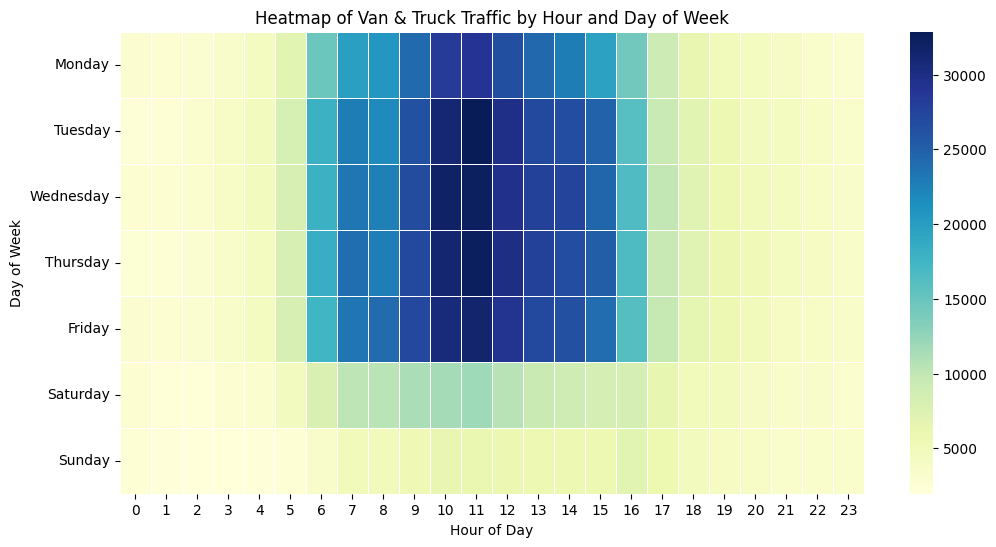

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot table for heatmap
heatmap_data = van_truck_df.pivot_table(
    index="day_of_week", columns="hour", values="vehicle_count", aggfunc="sum"
)

# Reorder days
days_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap of Van & Truck Traffic by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

**Key Insights — Delivery Demand by Hour and Day**

Peak Delivery Hours (Weekdays)
Delivery demand is highest between 9 AM and 2 PM from Monday to Friday, with the most intense activity occurring around 10 AM to 12 PM. This indicates that most logistics operations are concentrated during late morning hours.

Midweek Demand is Highest
Tuesday, Wednesday, and Thursday show the highest overall traffic intensity, suggesting these are the busiest days for delivery operations.

Lower Demand on Weekends
Both Saturday and Sunday exhibit significantly lower traffic levels across all hours, indicating reduced logistics activity compared to weekdays.

Early Morning and Late Night Are Quiet
Delivery demand is minimal during late night (8 PM – 5 AM) and early morning hours, suggesting these are low-activity periods in the transport network.

Gradual Build-Up in Morning
Traffic begins to increase from around 6 AM, peaks mid-day, and then gradually declines after 3 PM, showing a typical daily logistics cycle.

**Top Locations Analysis — Delivery Demand Hotspots**

This visualization identifies the top 10 locations with the highest van and truck traffic, which serve as key indicators of delivery demand across the city.

Approach:

The dataset is aggregated by location to calculate total vehicle counts.
The top 10 locations are selected based on the highest traffic volumes.
A horizontal bar chart is used to improve readability of location names.

Interpretation:

Higher vehicle counts indicate greater delivery and logistics activity.
These locations represent major demand hotspots within the urban transport network.

This analysis helps city planners and logistics operators identify critical areas that may require traffic management strategies, infrastructure improvements, or optimized delivery scheduling.

/tmp/ipykernel_7962/4190856967.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




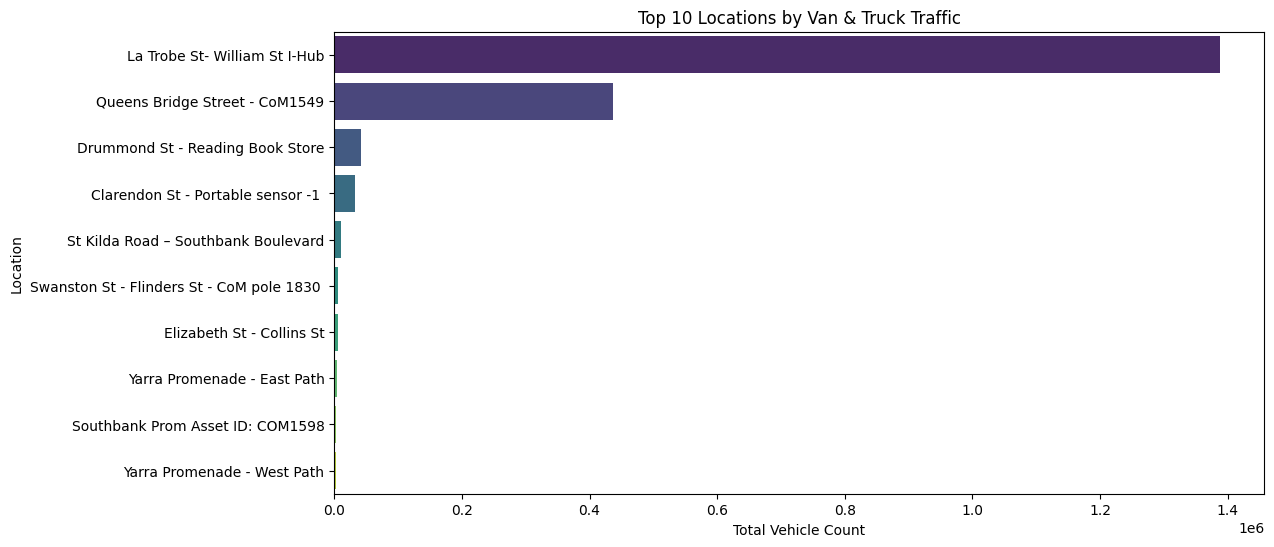

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 locations by total traffic
top10_locations = location_agg.sort_values("vehicle_count", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_locations,
    x="vehicle_count",
    y="location_name",
    palette="viridis"
)
plt.title("Top 10 Locations by Van & Truck Traffic")
plt.xlabel("Total Vehicle Count")
plt.ylabel("Location")
plt.show()

**Monthly Trend Analysis — Delivery Demand Over Time**

This visualization illustrates the monthly trends in van and truck traffic, providing insights into how delivery demand changes throughout the year.

Approach:

The data is grouped by year and month, and total vehicle counts are calculated.
A line chart is used to compare monthly trends across multiple years, with each year represented by a separate line.

Interpretation:

Peaks in the lines indicate periods of higher delivery demand, which may be influenced by seasonal factors such as holidays or increased commercial activity.
Comparing trends across years helps identify consistent seasonal patterns as well as any growth or decline in logistics activity over time.

This analysis supports better planning of delivery operations, resource allocation, and forecasting of future logistics demand.

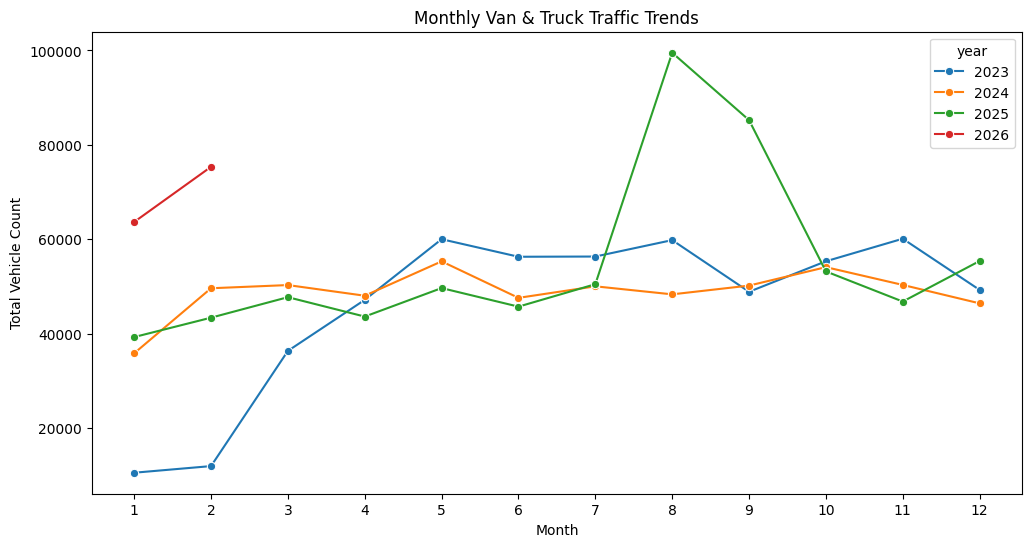

In [18]:
monthly_trend = van_truck_df.groupby(["year", "month"])["vehicle_count"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_trend, x="month", y="vehicle_count", hue="year", marker="o", palette="tab10")
plt.title("Monthly Van & Truck Traffic Trends")
plt.xlabel("Month")
plt.ylabel("Total Vehicle Count")
plt.xticks(range(1,13))
plt.show()

**Key Insights — Monthly Delivery Demand Trends**
Strong Seasonal Spike in 2025
A significant surge in delivery demand is observed in August and September 2025, where vehicle counts sharply increase compared to other months and years. This indicates a major seasonal or event-driven spike in logistics activity.

Stable Patterns in 2024
The year 2024 shows relatively consistent delivery demand across all months, with only minor fluctuations. This suggests a stable and predictable logistics environment during that year.

Growth Trend in Early 2023
In 2023, delivery demand starts low in the early months and increases steadily until mid-year, indicating a recovery or ramp-up in logistics activity.

Higher Demand in Early 2026
The available data for 2026 (first two months) shows higher vehicle counts compared to previous years, suggesting a potential increase in logistics demand continuing into 2026.


**Spatial-Temporal Analysis — Delivery Demand Trends for Top 5 Locations**

This visualization explores how delivery demand evolves over time at the top 5 busiest locations, providing a combined spatial and temporal perspective.

Approach:

The top 5 locations are identified based on total vehicle counts (highest delivery demand).
Data is aggregated on a weekly basis to smooth daily fluctuations.
A 5-week rolling average is applied to highlight underlying trends and reduce short-term variability.
An interactive line chart is created using Plotly, allowing comparison across locations.

Interpretation:

Each line represents delivery demand trends at a specific location.
Parallel trends suggest common, city-wide factors influencing logistics demand.
Diverging trends indicate location-specific patterns, such as unique traffic conditions or commercial activity.

This analysis helps determine whether delivery demand behaves consistently across the city or varies by location, supporting more targeted logistics planning and forecasting.

In [28]:
import plotly.express as px

# Identify top 5 busiest locations
top5_locations = location_agg.sort_values("vehicle_count", ascending=False).head(5)["location_name"].tolist()
top5_df = van_truck_df[van_truck_df["location_name"].isin(top5_locations)].copy()

# Weekly aggregation
top5_df['week'] = top5_df['start_time'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_agg = top5_df.groupby(['week', 'location_name'])['vehicle_count'].sum().reset_index()
weekly_agg['rolling_avg'] = weekly_agg.groupby('location_name')['vehicle_count'].transform(lambda x: x.rolling(5, min_periods=1).mean())

# Plot interactive line chart
fig = px.line(
    weekly_agg,
    x="week",
    y="rolling_avg",
    color="location_name",
    markers=True,
    title="Weekly Delivery Demand Trends for Top 5 Locations",
    labels={"rolling_avg":"Vehicle Count (5-week avg)", "week":"Week"}
)
fig.show()

/tmp/ipykernel_7962/4033814208.py:8: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



**Key Insights — Weekly Delivery Demand Trends**

Consistent High Demand at Key Location
La Trobe St – William St I-Hub shows significantly higher delivery demand compared to other locations throughout the entire period, indicating it is a major logistics hotspot in the city.

Seasonal Spike in 2025
A sharp increase in delivery demand is observed around mid-to-late 2025 across multiple locations, especially at La Trobe St and Queens Bridge Street. This suggests a city-wide surge, potentially driven by seasonal factors such as peak retail or holiday demand.

Stable vs Volatile Locations
Locations like Queens Bridge Street show relatively stable demand with minor fluctuations, indicating consistent traffic flow.
In contrast, La Trobe St exhibits higher volatility, suggesting sensitivity to external factors such as events, infrastructure changes, or commercial activity.

Low but Growing Demand Locations
Locations such as St Kilda Road and Drummond St have comparatively lower demand but show gradual growth over time, indicating emerging logistics activity in these areas.
